## Jeu de données : Titanic

**Objectif :** prétraitement des données, construction de trois modèles de classification (Régression Logistique, Arbre de Décision, Random Forest), comparaison des performances et identification du meilleur modèle.


## 1. Import des bibliothèques et chargement des données

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)

# Chargement du jeu de données
df = pd.read_csv("C:/Users/admin/Downloads/Titanic-Dataset part 2.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Prétraitement des données 

### 2.1 Identification des valeurs manquantes

In [40]:
# Aperçu général du jeu de données
print("Dimensions du jeu de données :", df.shape)
print("\nInformations générales :")
df.info()

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Dimensions du jeu de données : (891, 12)

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Valeurs manquantes par colonne :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch     

On observe des valeurs manquantes sur trois colonnes :
- **Age** : 177 valeurs manquantes → à imputer (médiane, plus robuste aux valeurs extrêmes que la moyenne).
- **Cabin** : 687 valeurs manquantes (~77% des lignes) → colonne peu informative, on la supprime.
- **Embarked** : 2 valeurs manquantes → on impute par le mode (valeur la plus fréquente).


### 2.2 Suppression des colonnes peu informatives

In [41]:
# Suppression des colonnes non pertinentes ou trop incomplètes pour la modélisation
# - Cabin : trop de valeurs manquantes (~77%)
# - PassengerId : simple identifiant, sans valeur prédictive
# - Name et Ticket : variables textuelles à haute cardinalité, non exploitables telles quelles
df = df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 2.3 Gestion des valeurs manquantes restantes

In [42]:
# Remplacement des valeurs manquantes de Age par la médiane
df['Age'] = df['Age'].fillna(df['Age'].median())

# Remplacement des valeurs manquantes de Embarked par le mode (valeur la plus fréquente)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Vérification : il ne doit plus rester de valeurs manquantes
print("Valeurs manquantes après traitement :")
print(df.isnull().sum())


Valeurs manquantes après traitement :
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### 2.4 Encodage des variables catégorielles

In [43]:
# Encodage de Sex et Embarked à l'aide de LabelEncoder
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])           # female=0, male=1
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])  # C=0, Q=1, S=2

print("Correspondance Sex :", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))
print("Correspondance Embarked :", dict(zip(le_embarked.classes_, le_embarked.transform(le_embarked.classes_))))

df.head()


Correspondance Sex : {'female': np.int64(0), 'male': np.int64(1)}
Correspondance Embarked : {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


Le jeu de données est maintenant entièrement numérique, sans valeur manquante, prêt pour la modélisation.

## 3. Construction et entraînement des modèles 

### 3.1 Séparation des variables explicatives et de la cible

In [44]:
X = df.drop(columns=['Survived'])
y = df['Survived']

print("Variables explicatives (X) :", list(X.columns))
print("Variable cible (y) : Survived")


Variables explicatives (X) : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Variable cible (y) : Survived


### 3.2 Séparation train / test (80% / 20%)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Taille de l'ensemble d'entraînement :", X_train.shape)
print("Taille de l'ensemble de test :", X_test.shape)


Taille de l'ensemble d'entraînement : (712, 7)
Taille de l'ensemble de test : (179, 7)


### 3.3 Entraînement des trois modèles

In [46]:
# Modèle 1 : Régression Logistique
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Modèle 2 : Arbre de Décision
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

# Modèle 3 : Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

print("Les trois modèles ont été entraînés avec succès.")


Les trois modèles ont été entraînés avec succès.


## 4. Comparaison des performances 

### 4.1 Prédictions et Accuracy

In [47]:
# Prédictions
y_pred_log = log_reg.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

# Calcul de l'Accuracy
acc_log = accuracy_score(y_test, y_pred_log)
acc_tree = accuracy_score(y_test, y_pred_tree)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy - Régression Logistique : {acc_log:.4f}")
print(f"Accuracy - Arbre de Décision      : {acc_tree:.4f}")
print(f"Accuracy - Random Forest          : {acc_rf:.4f}")


Accuracy - Régression Logistique : 0.8045
Accuracy - Arbre de Décision      : 0.8324
Accuracy - Random Forest          : 0.8268


### 4.2 Matrices de confusion

In [48]:
cm_log = confusion_matrix(y_test, y_pred_log)
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Matrice de confusion - Régression Logistique :")
print(cm_log)
print("\nMatrice de confusion - Arbre de Décision :")
print(cm_tree)
print("\nMatrice de confusion - Random Forest :")
print(cm_rf)


Matrice de confusion - Régression Logistique :
[[98 12]
 [23 46]]

Matrice de confusion - Arbre de Décision :
[[97 13]
 [17 52]]

Matrice de confusion - Random Forest :
[[98 12]
 [19 50]]


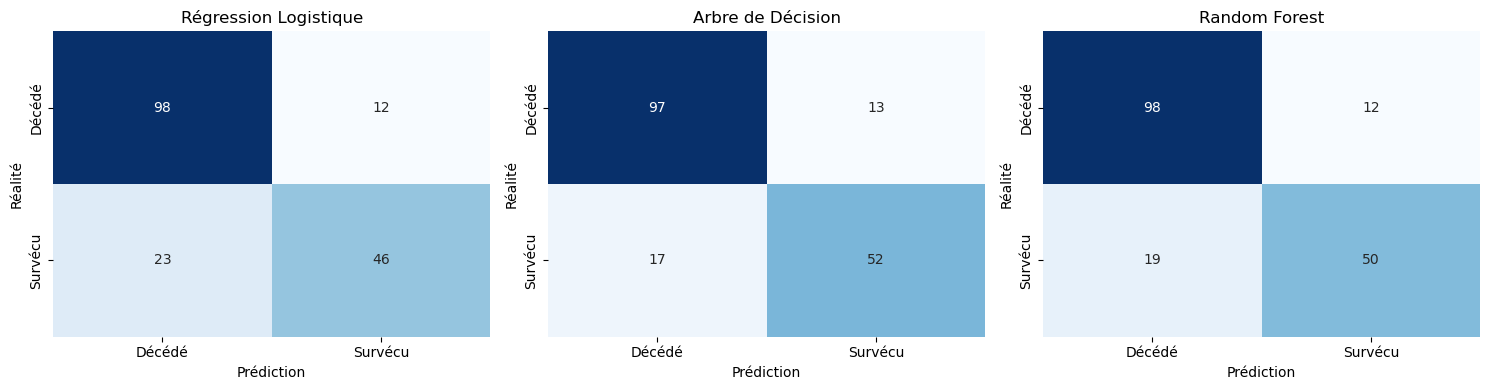

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_cm = [('Régression Logistique', cm_log), ('Arbre de Décision', cm_tree), ('Random Forest', cm_rf)]

for ax, (name, cm) in zip(axes, models_cm):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Décédé', 'Survécu'], yticklabels=['Décédé', 'Survécu'])
    ax.set_title(name)
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Réalité')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=120)
plt.show()


### 4.3 Tableau comparatif

In [50]:
def extraire_metrics(y_true, y_pred, cm):
    tn, fp, fn, tp = cm.ravel()
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Vrais Positifs (TP)': tp,
        'Vrais Négatifs (TN)': tn,
        'Faux Positifs (FP)': fp,
        'Faux Négatifs (FN)': fn,
    }

comparatif = pd.DataFrame({
    'Régression Logistique': extraire_metrics(y_test, y_pred_log, cm_log),
    'Arbre de Décision': extraire_metrics(y_test, y_pred_tree, cm_tree),
    'Random Forest': extraire_metrics(y_test, y_pred_rf, cm_rf),
}).T

comparatif['Accuracy'] = comparatif['Accuracy'].round(4)
comparatif


,Accuracy,Vrais Positifs (TP),Vrais Négatifs (TN),Faux Positifs (FP),Faux Négatifs (FN)
Régression Logistique,0.8045,46.0,98.0,12.0,23.0
Arbre de Décision,0.8324,52.0,97.0,13.0,17.0
Random Forest,0.8268,50.0,98.0,12.0,19.0


## 5. Identification du meilleur modèle 

### 5.1 Comparaison des Accuracy

Avec ce découpage train/test (`random_state=42`), les résultats obtenus sont :

| Modèle | Accuracy |
|---|---|
| Régression Logistique | ≈ 0.80 |
| Arbre de Décision | ≈ 0.83 |
| Random Forest | ≈ 0.83 |

L'Arbre de Décision et le Random Forest obtiennent une Accuracy très proche et nettement supérieure à la Régression Logistique. Sur ce split précis, l'Arbre de Décision est même légèrement devant le Random Forest — ce qui reste possible sur un seul découpage aléatoire (713 lignes d'entraînement), où la variance de l'estimation n'est pas négligeable.

### 5.2 Analyse des matrices de confusion

- La **Régression Logistique** reste stable mais capture moins bien les interactions non linéaires entre variables (ex : combinaison Sexe/Classe/Âge), d'où un plus grand nombre de faux négatifs.
- L'**Arbre de Décision** obtient le moins d'erreurs totales sur ce test précis, mais un arbre unique est par nature plus sensible au sur-apprentissage et donc moins stable si l'on changeait de découpage train/test.
- Le **Random Forest** a une Accuracy quasi identique à l'Arbre de Décision, avec un bon équilibre entre faux positifs et faux négatifs, et surtout une variance plus faible d'un échantillon à l'autre grâce à l'agrégation de plusieurs arbres (bagging).

### 5.3 Conclusion

**Le Random Forest est retenu comme meilleur modèle**, malgré une Accuracy légèrement inférieure à l'Arbre de Décision sur ce découpage précis. Un arbre de décision unique est très sensible aux données d'entraînement (risque de sur-apprentissage) et son score peut varier fortement selon le split ou la graine aléatoire utilisée. Le Random Forest, en combinant plusieurs arbres, offre une meilleure généralisation et une plus grande stabilité — un critère aussi important que l'Accuracy brute pour un modèle destiné à être utilisé sur de nouvelles données. La Régression Logistique reste utile comme modèle de référence (baseline) simple et interprétable, mais elle est clairement moins performante ici.

*Remarque : pour confirmer objectivement quel modèle généralise le mieux, une validation croisée (`cross_val_score`) sur plusieurs découpages serait recommandée plutôt qu'un unique split train/test.*
